In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import stemgraphic
from datetime import datetime
import scipy
import scipy.stats
from scipy.stats import skew

In [17]:
data=pd.read_csv("D:\\FCDS\\Fall 24 - 25\\Probability & Stats 2\\StudentsPerformance.csv")


In [71]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [19]:
data.head() # to get a general overview the dataset

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [27]:
pd.set_option('display.max_columns', None)  # Show all columns 
pd.set_option('display.width', None)  # Disable line wrapping, adjust to your screen width

In [29]:
df=pd.DataFrame(data)
races = df['race/ethnicity'].nunique() # to get the number of races used in the dataset
print(races)

5


In [31]:
#returns Statistical Summary the count, mean, std, quartiles, min and max.
data.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [33]:
data.mode()  

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group C,some college,standard,none,65,72,74


#distribution


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silen

Text(0.5, 0, 'scores')

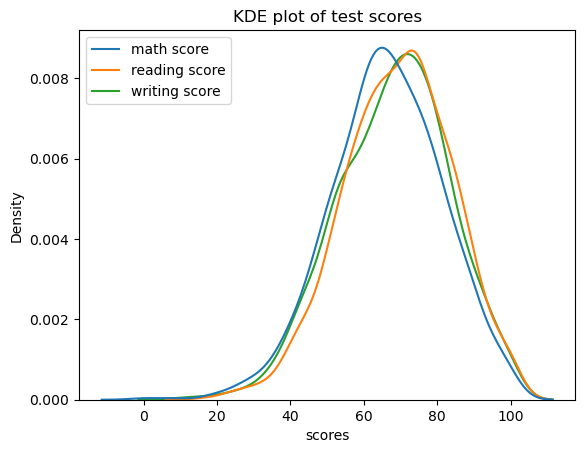

In [35]:
sns.kdeplot(data)
plt.title("KDE plot of test scores")
plt.xlabel("scores")

In [85]:
import math
bins_no = math.ceil(math.sqrt(1000)) # bin calculated by the formula ceil(sqroot(n)) = 32
print(bins_no)


32


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



Text(0.5, 1.0, 'A histogram of math scores')

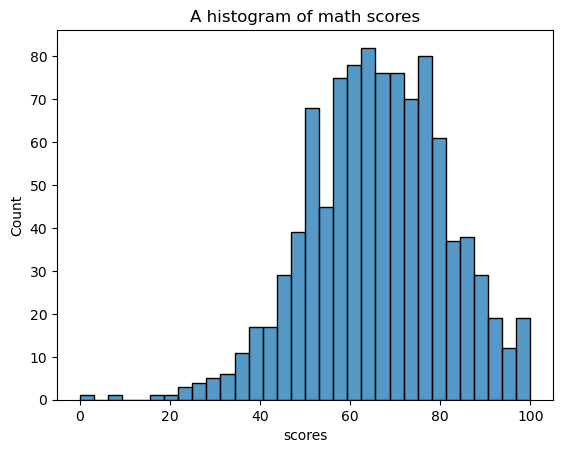

In [87]:
sns.histplot(data['math score'], bins=bins_no) 

plt.xlabel("scores")
plt.title("A histogram of math scores")

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



Text(0.5, 1.0, 'A histogram of reading scores')

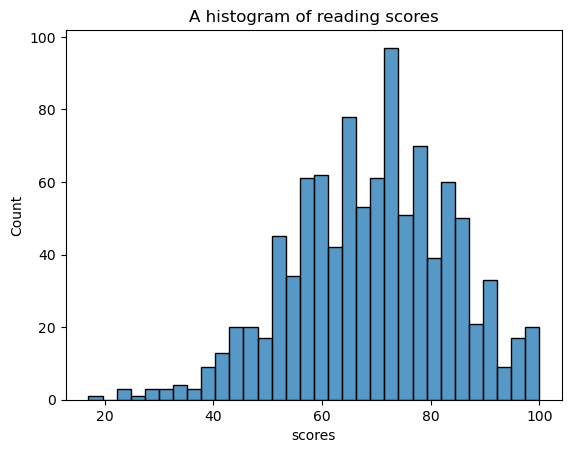

In [89]:
sns.histplot(data['reading score'], bins= bins_no)

plt.xlabel("scores")
plt.title("A histogram of reading scores")

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



Text(0.5, 1.0, 'A histogram of writing scores')

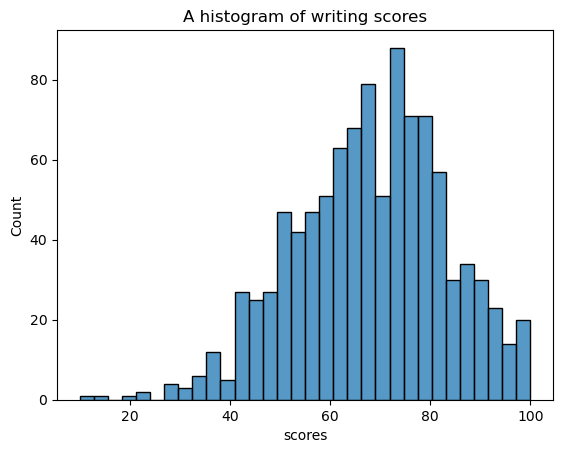

In [91]:
sns.histplot(data['writing score'], bins=bins_no) 
plt.xlabel("scores")
plt.title("A histogram of writing scores")

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



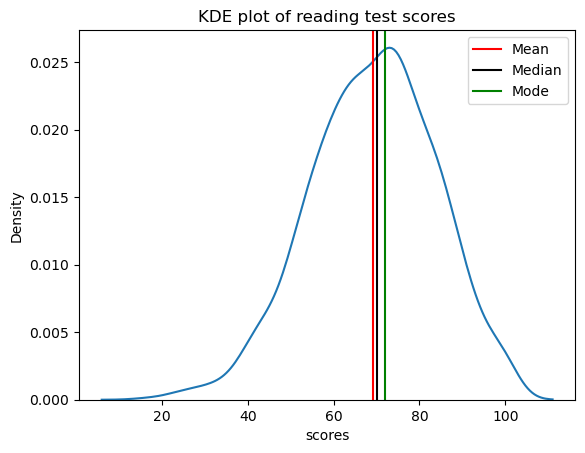

In [45]:
# Add vertical lines at the position of mean, median, mode
sns.kdeplot(data['reading score'])
plt.title("KDE plot of reading test scores")
plt.xlabel("scores")
mean_score= data['reading score'].mean()
median_score= data['reading score'].median()
mode_score= data['reading score'].mode().iloc[0]

plt.axvline(mean_score, color= "red",label="Mean")
plt.axvline(median_score, color="black", label="Median")
plt.axvline(mode_score, color="green", label="Mode")

plt.legend()
plt.show()
# the graph and the lines show us the left skewed as the mode> median> mean 

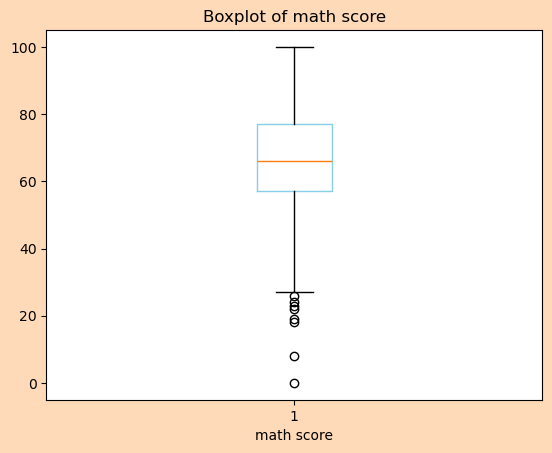

In [47]:
fig, axs = plt.subplots()
fig.set_facecolor('peachpuff')
axs.boxplot(df['math score'], vert=True, boxprops=dict(color='skyblue'))
axs.set_xlabel('math score')
axs.set_title('Boxplot of math score')
plt.show()

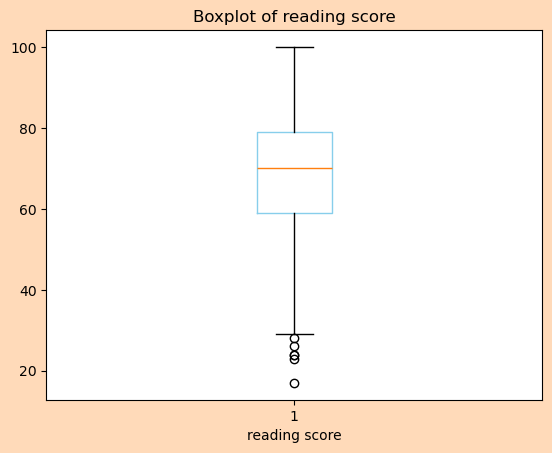

In [49]:

fig, axs = plt.subplots()
fig.set_facecolor('peachpuff')
axs.boxplot(df['reading score'], vert=True, boxprops=dict(color='skyblue'))
axs.set_xlabel('reading score')
axs.set_title('Boxplot of reading score')
plt.show()


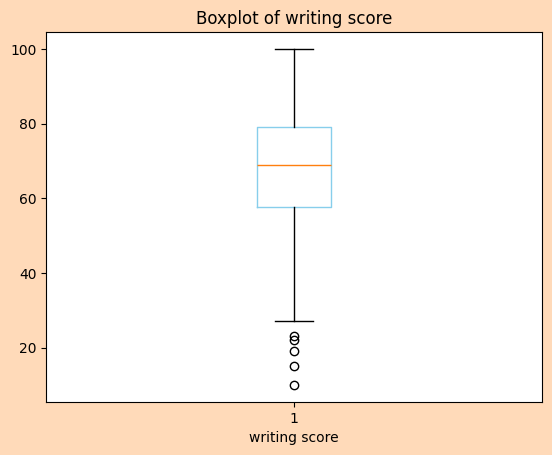

In [14]:

fig, axs = plt.subplots()
fig.set_facecolor('peachpuff')
axs.boxplot(df['writing score'], vert=True, boxprops=dict(color='skyblue'))
axs.set_xlabel('writing score')
axs.set_title('Boxplot of writing score')
plt.show()


In [51]:
# assigning the columns to variables to be easily retrieved in future use
math_scores = df["math score"]
reading_scores = df["reading score"]
writing_scores = df["writing score"]

(<Figure size 750x350 with 1 Axes>, <Axes: >)

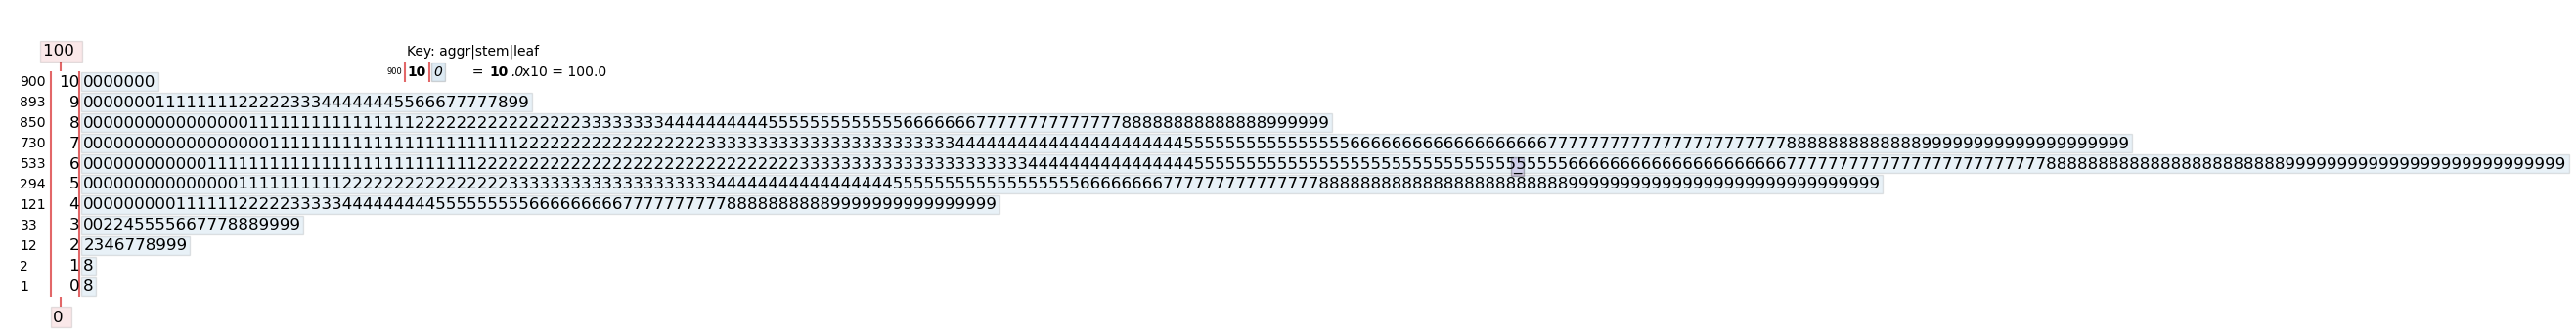

In [97]:
stemgraphic.stem_graphic(math_scores,scale=10)

(<Figure size 750x325 with 1 Axes>, <Axes: >)

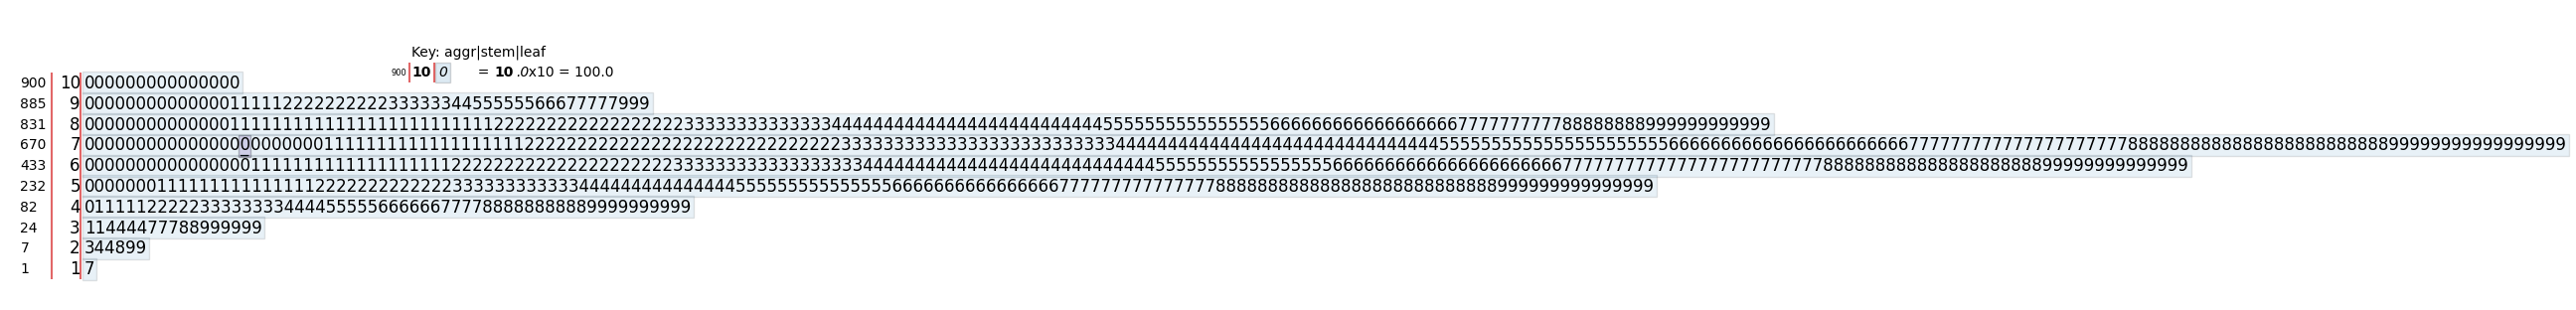

In [18]:
stemgraphic.stem_graphic(reading_scores,scale=10)

(<Figure size 750x325 with 1 Axes>, <Axes: >)

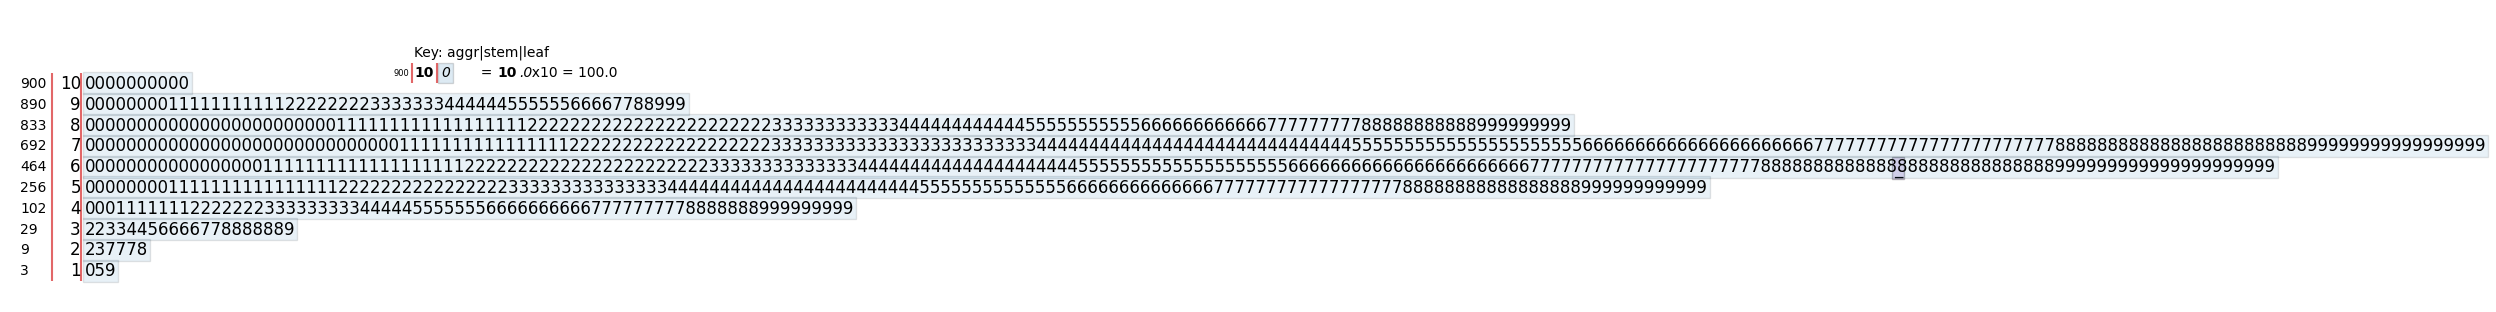

In [19]:
stemgraphic.stem_graphic(writing_scores,scale=10)

In [20]:
print(df.columns)

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')


In [107]:
def dotplots(x, x_label="Data Values"): 
    
 data = np.array(x)   # convert to array
 values, counts = np.unique(data, return_counts=True)

# dot plot with appropriate figure size and y-axis limits
 fig, ax = plt.subplots(figsize=(10, 4))
 for value, count in zip(values, counts):
    ax.plot([value]*count, list(range(count)), 'co', ms=10, linestyle='')
 for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
 ax.yaxis.set_visible(False)
 ax.set_ylim(-1, max(counts))
 ax.set_xticks(range(min(values), max(values)+1))
 ax.tick_params(axis='x', length=0, pad=8, labelsize=8)
 plt.xticks(rotation=45, ha='right')

 plt.suptitle("Dot Plot")
 plt.ylabel("frequency")
 plt.xlabel(x_label)

 return plt.show()

In [109]:
filtered_scores=math_scores[(math_scores>=50)&(math_scores<=100)]
filtered_reading=reading_scores[(reading_scores>=50)&(reading_scores<=100)]
filtered_writing=writing_scores[(writing_scores>=50)&(writing_scores<=100)]

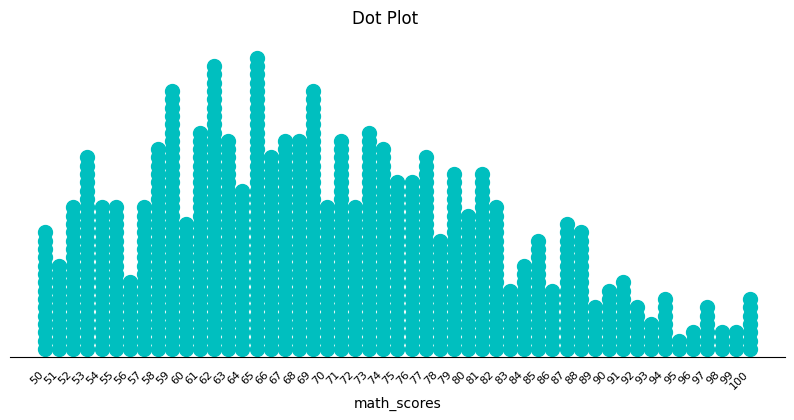

In [25]:
dotplots(filtered_scores,x_label="math_scores")

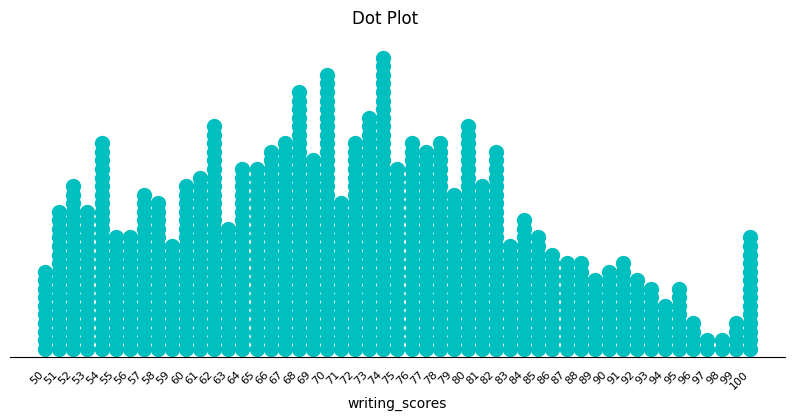

In [31]:
dotplots(filtered_writing,x_label="writing_scores")

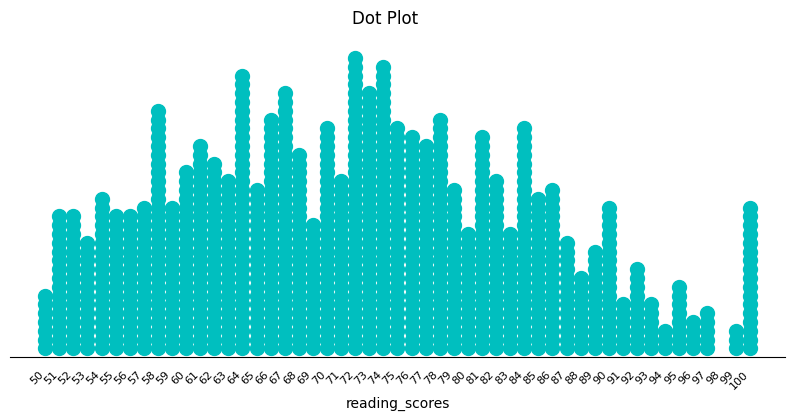

In [32]:
dotplots(filtered_reading,x_label="reading_scores")

In [111]:

def skew_type(sq):
    if sq == 0:
        print("it is normally distributed")
    elif sq > 0:
        print("it is left skewed")
    elif sq < 0:
        print("it is right skewed")


In [113]:

def kurt_type(krt):
    if krt == 3:
        print("it is normally distributed")
    elif krt < 3:
        print("it is playkurtic")
    elif krt > 3:
        print("it is leptokurtic(have outlires compared to normal dist.)")


In [115]:

math_skewness = scipy.stats.skew(math_scores,axis=0,bias=True)
reading_skewness = scipy.stats.skew(reading_scores,axis=0,bias=True)
writing_skewness = scipy.stats.skew(writing_scores,axis=0,bias=True)

math_kurtosis= scipy.stats.kurtosis(math_scores,axis=0,bias=True)
reading_kurtosis= scipy.stats.kurtosis(reading_scores,axis=0,bias=True)
writing_kurtosis= scipy.stats.kurtosis(writing_scores,axis=0,bias=True)


In [117]:

print("math_skewness:",math_skewness,skew_type(math_skewness))
print("reading_skewness:",reading_skewness,skew_type(reading_skewness))
print("writing_skewness:",writing_skewness,skew_type(writing_skewness))

print("math_kurtosis",math_kurtosis, kurt_type(math_kurtosis))
print("reading_kurtosis:",reading_kurtosis, kurt_type(reading_kurtosis))
print("writing_kurtosis:",writing_kurtosis, kurt_type(writing_kurtosis))


it is right skewed
math_skewness: -0.278516571914075 None
it is right skewed
reading_skewness: -0.25871569927829347 None
it is right skewed
writing_skewness: -0.28900962452114176 None
it is playkurtic
math_kurtosis 0.26759715461497846 None
it is playkurtic
reading_kurtosis: -0.07391861478331307 None
it is playkurtic
writing_kurtosis: -0.03919203131162252 None


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



Axes(0.125,0.11;0.775x0.77)


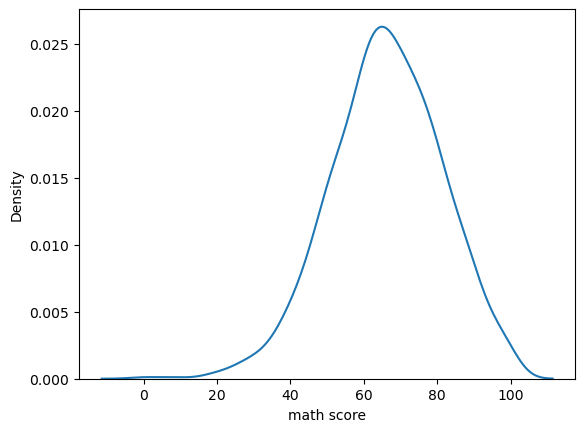

In [119]:

print(sns.kdeplot(math_scores))



C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



Axes(0.125,0.11;0.775x0.77)


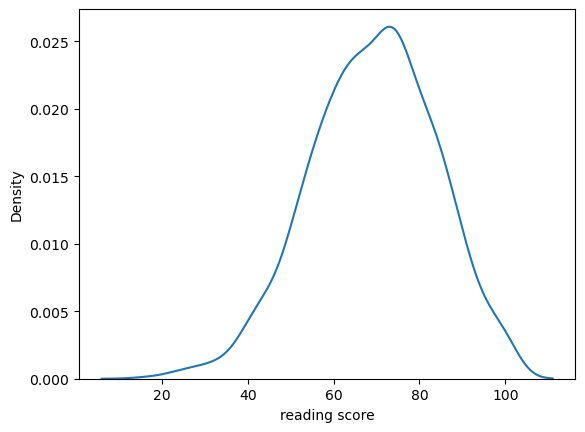

In [120]:
print(sns.kdeplot(reading_scores))

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



Axes(0.125,0.11;0.775x0.77)


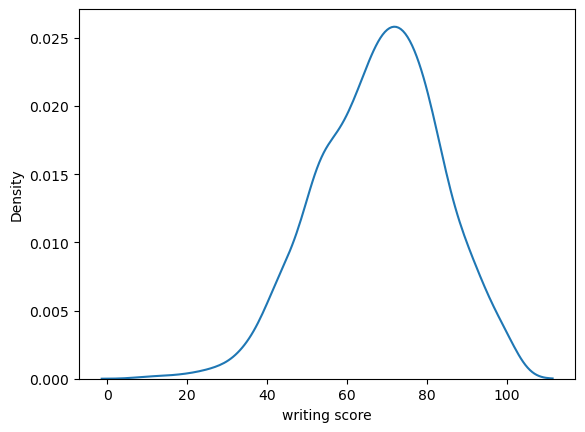

In [122]:
print(sns.kdeplot(writing_scores    ))

In [125]:
grouped_dataframes = {}
for group, group_df in df.groupby('race/ethnicity'):
    grouped_dataframes[group] = group_df


In [127]:
df_A = grouped_dataframes['group A']
df_B = grouped_dataframes['group B']
df_C = grouped_dataframes['group C']
df_D = grouped_dataframes['group D']
df_E = grouped_dataframes['group E']

In [129]:
mf,mp = scipy.stats.f_oneway(df_A['math score'],
                           df_B['math score'],
                           df_C['math score'],
                           df_D['math score'],
                           df_E['math score'])

In [131]:
rf,rp = scipy.stats.f_oneway(df_A['reading score'],
                           df_B['reading score'],
                           df_C['reading score'],
                           df_D['reading score'],
                           df_E['reading score'])

In [133]:
wf,wp = scipy.stats.f_oneway(df_A['writing score'],
                           df_B['writing score'],
                           df_C['writing score'],
                           df_D['writing score'],
                           df_E['writing score'])

In [135]:
print(f"The F value is {mf}\nAnd the P value is {mp}")

The F value is 14.593885166332635
And the P value is 1.3732194030370688e-11
